In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Scatter Plot

In [2]:
actors = Table.read_table('data/actors.csv')
# money amounts are in millions of dollars
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


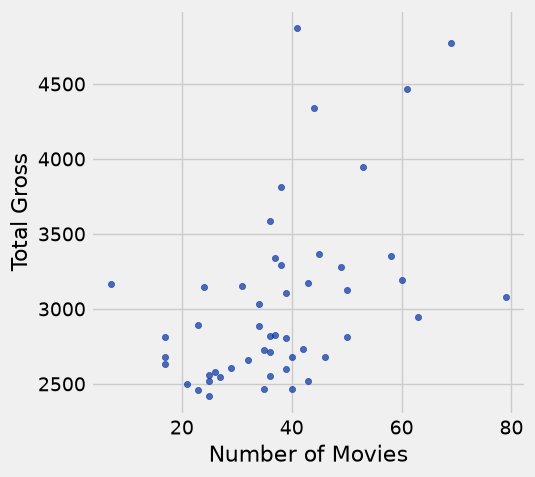

In [5]:
actors.scatter('Number of Movies', 'Total Gross')

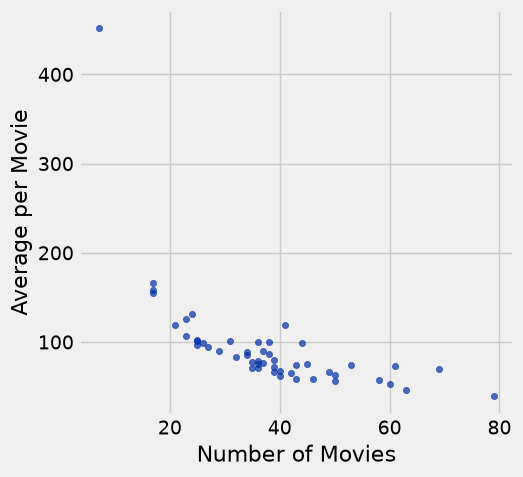

In [6]:
actors.scatter('Number of Movies', 'Average per Movie')

In [7]:
# an outlier!

In [8]:
actors.where('Number of Movies', are.below(10))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


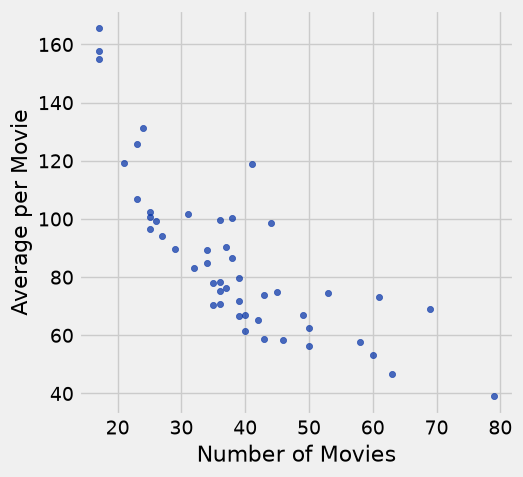

In [9]:
actors.where('Number of Movies', are.above(10)).scatter('Number of Movies', 'Average per Movie')

# Line Plots

In [10]:
movies_by_year = Table.read_table('data/movies-by-year.csv')
movies_by_year

Year,Total Gross,Number of Movies,#1 Movie
2015,11128.5,702,Star Wars: The Force Awakens
2014,10360.8,702,American Sniper
2013,10923.6,688,Catching Fire
2012,10837.4,667,The Avengers
2011,10174.3,602,Harry Potter / Deathly Hallows (P2)
2010,10565.6,536,Toy Story 3
2009,10595.5,521,Avatar
2008,9630.7,608,The Dark Knight
2007,9663.8,631,Spider-Man 3
2006,9209.5,608,Dead Man's Chest


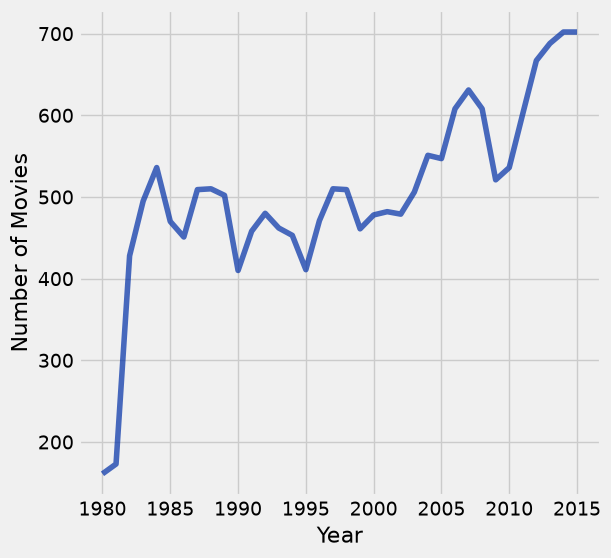

In [12]:
movies_by_year.plot('Year', 'Number of Movies')
# see the recession?

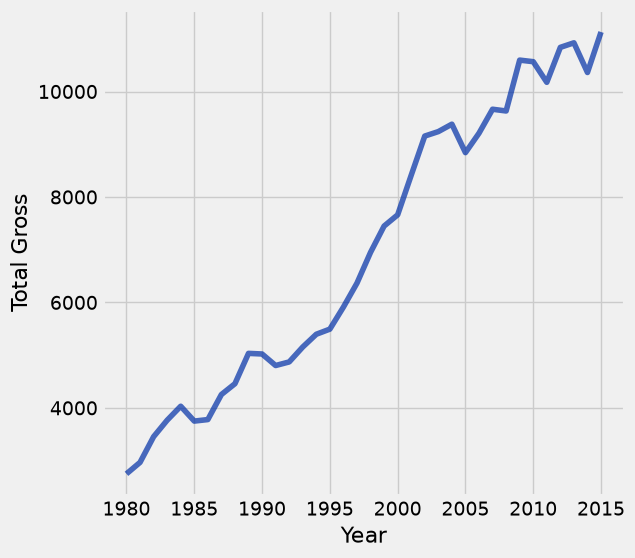

In [13]:
movies_by_year.plot('Year', 'Total Gross')

In [15]:
# can't start a variable name with numbers :(
century_21 = movies_by_year.where('Year', are.above(1999))

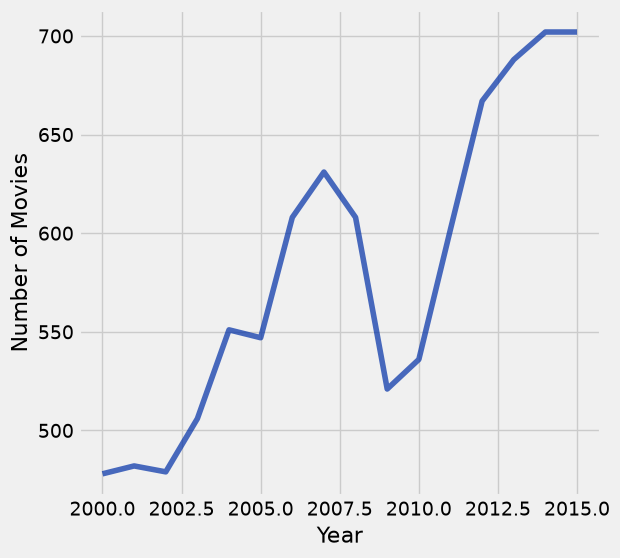

In [16]:
century_21.plot('Year', 'Number of Movies')

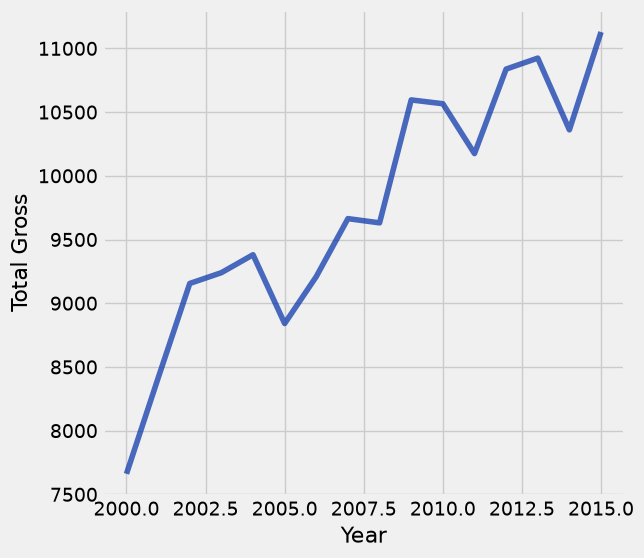

In [17]:
century_21.plot('Year', 'Total Gross')

In [18]:
century_21.where('Year', 2010)

Year,Total Gross,Number of Movies,#1 Movie
2010,10565.6,536,Toy Story 3


In [19]:
temps = Table.read_table('data/max-min-temperatures-fresno-up-to-2025.csv')
temps

Date,Highest High,Highest High Year,Lowest Low,Lowest Low Year
01/01,69,1998,21,1976
01/02,70,1948,20,1976
01/03,72,1948,23,1976
01/04,71,1948,22,1976
01/05,72,2018,20,1949
01/06,73,1948,17,1913
01/07,71,1911,20,1913
01/08,72,1911,22,1888
01/09,70,1953,23,1949
01/10,68,2025,18,1949


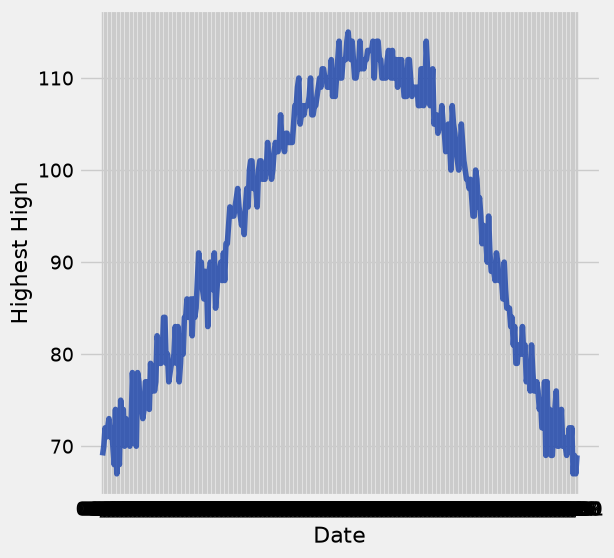

In [20]:
temps.plot('Date', 'Highest High')

In [21]:
Table.interactive_plots()

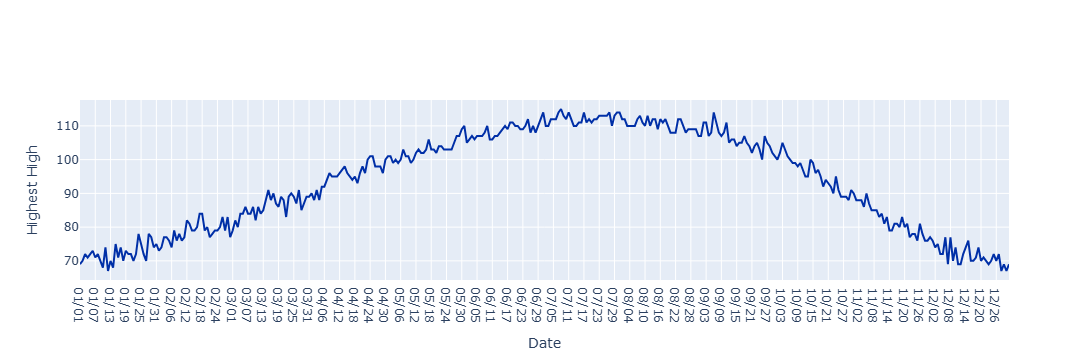

In [22]:
temps.plot('Date', 'Highest High')

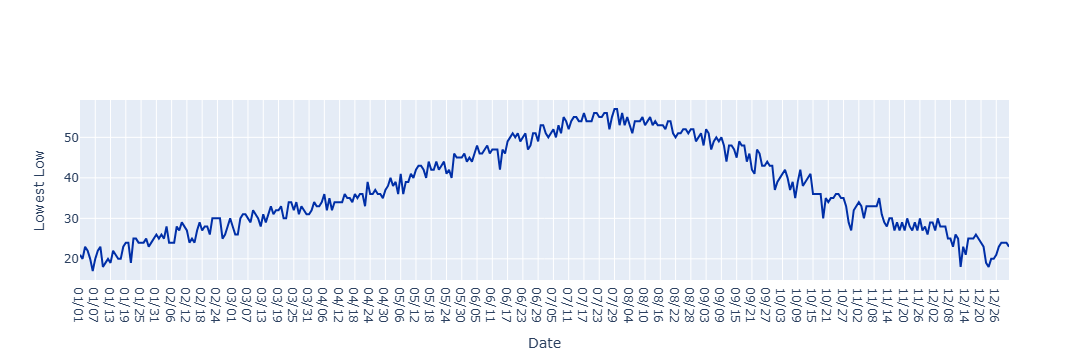

In [23]:
temps.plot('Date', 'Lowest Low')

In [24]:
Table.static_plots()

In [25]:
temps

Date,Highest High,Highest High Year,Lowest Low,Lowest Low Year
01/01,69,1998,21,1976
01/02,70,1948,20,1976
01/03,72,1948,23,1976
01/04,71,1948,22,1976
01/05,72,2018,20,1949
01/06,73,1948,17,1913
01/07,71,1911,20,1913
01/08,72,1911,22,1888
01/09,70,1953,23,1949
01/10,68,2025,18,1949


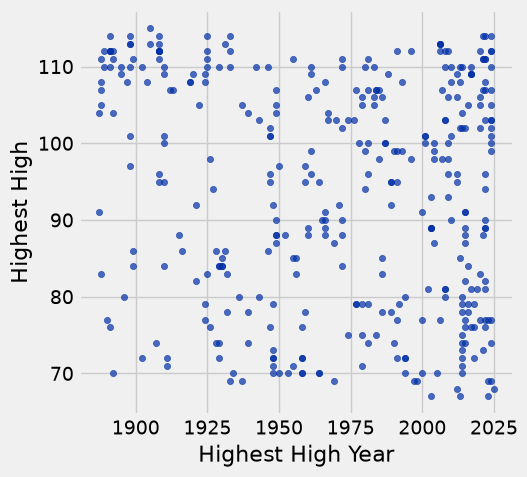

In [26]:
temps.scatter('Highest High Year', 'Highest High')

# Bar Charts

In [28]:
icecream = Table().with_columns(
    'Flavor', make_array('Chocolate', 'Strawberry', 'Vanilla'),
    'Number of Cartons', make_array(16, 5, 9)
)
icecream

Flavor,Number of Cartons
Chocolate,16
Strawberry,5
Vanilla,9


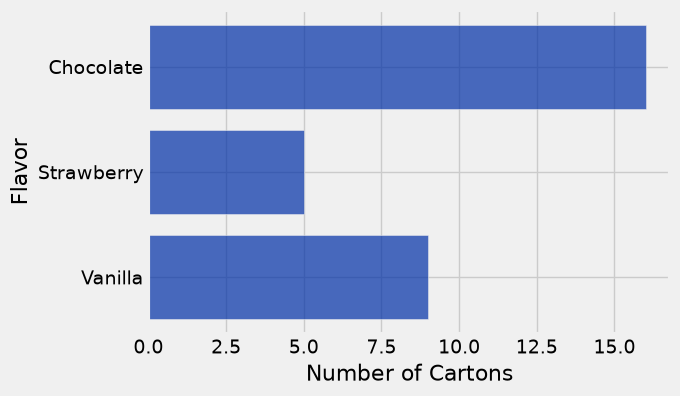

In [30]:
icecream.barh('Flavor', 'Number of Cartons') # could've skipped the second argument
# shows the *distribution* of cartons of each flavor

In [31]:
top = Table.read_table('data/top-movies-2017.csv')
top

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista (Disney),906723418,906723400,2015
Avatar,Fox,760507625,846120800,2009
Titanic,Paramount,658672302,1178627900,1997
Jurassic World,Universal,652270625,687728000,2015
Marvel's The Avengers,Buena Vista (Disney),623357910,668866600,2012
The Dark Knight,Warner Bros.,534858444,647761600,2008
Star Wars: Episode I - The Phantom Menace,Fox,474544677,785715000,1999
Star Wars,Fox,460998007,1549640500,1977
Avengers: Age of Ultron,Buena Vista (Disney),459005868,465684200,2015
The Dark Knight Rises,Warner Bros.,448139099,500961700,2012


In [32]:
top.select('Title', 'Studio')

Title,Studio
Star Wars: The Force Awakens,Buena Vista (Disney)
Avatar,Fox
Titanic,Paramount
Jurassic World,Universal
Marvel's The Avengers,Buena Vista (Disney)
The Dark Knight,Warner Bros.
Star Wars: Episode I - The Phantom Menace,Fox
Star Wars,Fox
Avengers: Age of Ultron,Buena Vista (Disney)
The Dark Knight Rises,Warner Bros.


In [34]:
top.select('Title', 'Studio').where('Studio', 'Fox').num_rows

26

In [37]:
studio_distribution = top.select('Title', 'Studio').group('Studio')
studio_distribution

Studio,count
AVCO,1
Buena Vista (Disney),29
Columbia,10
Disney,11
Dreamworks,3
Fox,26
IFC,1
Lionsgate,3
MGM,7
MPC,1


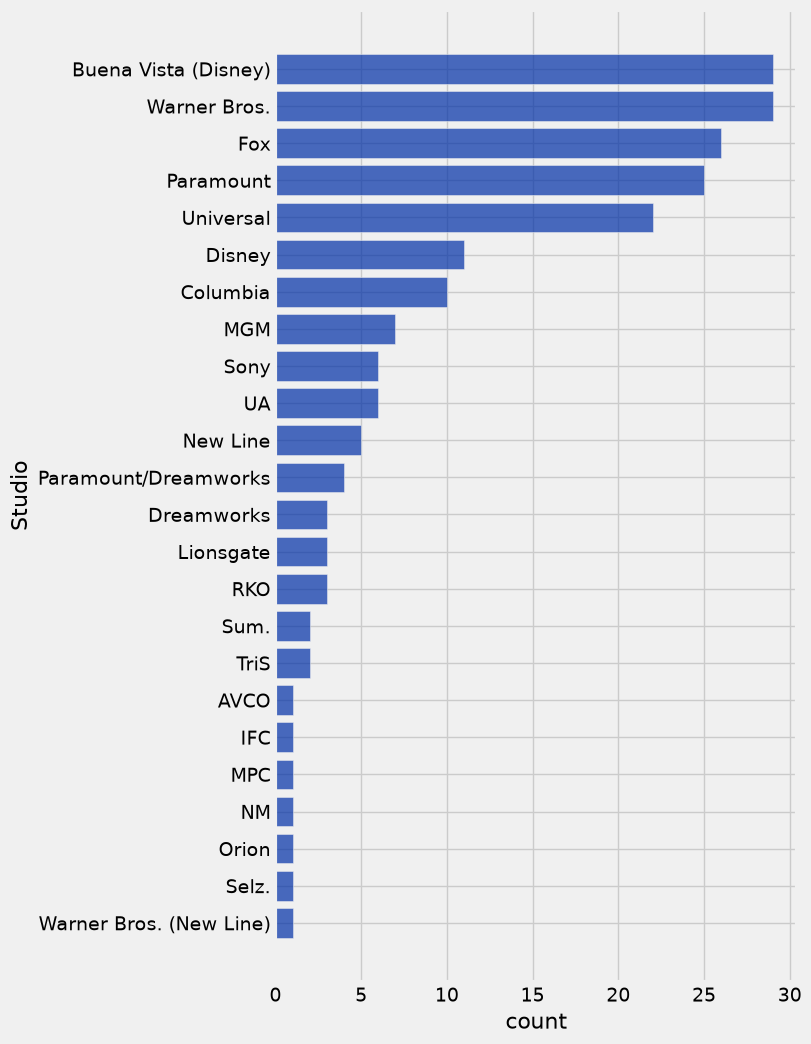

In [41]:
studio_distribution.sort('count', descending=True).barh('Studio')

In [42]:
titanic = Table.read_table('data/titanic.csv')
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.4583,nan,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C


In [44]:
titanic_survivors = titanic.where('Survived', 1)
titanic_survivors

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S
12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S
16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55,0,0,248706,16,nan,S
18,1,2,"Williams, Mr. Charles Eugene",male,nan,0,0,244373,13,nan,S
20,1,3,"Masselmani, Mrs. Fatima",female,nan,0,0,2649,7.225,nan,C


In [47]:
first_class_survivor_count = titanic_survivors.where('Pclass', 1).num_rows
first_class_survivor_count

136

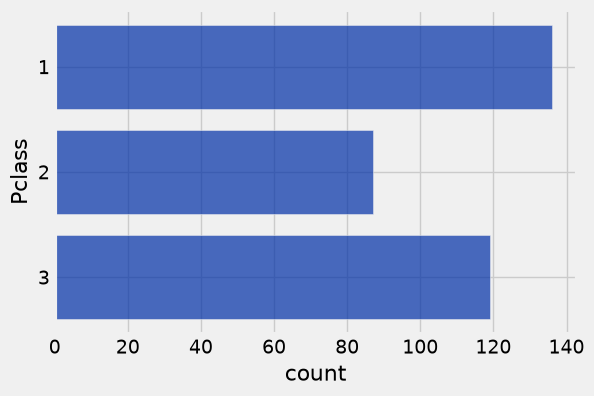

In [49]:
titanic_survivors.group('Pclass').barh('Pclass')

In [51]:
titanic.group('Pclass')

Pclass,count
1,216
2,184
3,491


In [52]:
titanic_survivors.group('Pclass')

Pclass,count
1,136
2,87
3,119


In [54]:
titanic_survivors.group('Pclass').column('count') / titanic.group('Pclass').column('count')

array([ 0.62962963,  0.47282609,  0.24236253])

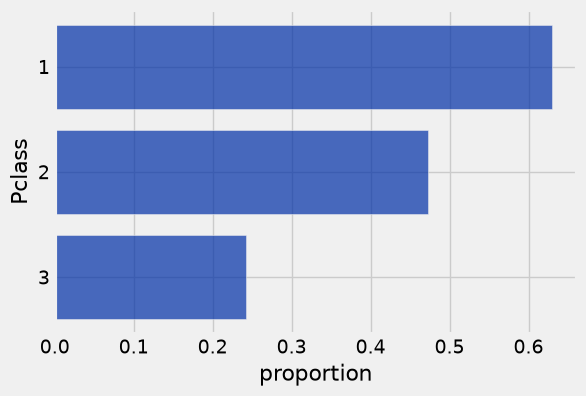

In [56]:
Table().with_columns(
    'Pclass', make_array(1, 2, 3),
    'proportion', titanic_survivors.group('Pclass').column('count') / titanic.group('Pclass').column('count')
).barh('Pclass')

# Distributions, Bins, and Histograms

In [57]:
top

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista (Disney),906723418,906723400,2015
Avatar,Fox,760507625,846120800,2009
Titanic,Paramount,658672302,1178627900,1997
Jurassic World,Universal,652270625,687728000,2015
Marvel's The Avengers,Buena Vista (Disney),623357910,668866600,2012
The Dark Knight,Warner Bros.,534858444,647761600,2008
Star Wars: Episode I - The Phantom Menace,Fox,474544677,785715000,1999
Star Wars,Fox,460998007,1549640500,1977
Avengers: Age of Ultron,Buena Vista (Disney),459005868,465684200,2015
The Dark Knight Rises,Warner Bros.,448139099,500961700,2012


In [58]:
top.set_format(make_array(2, 3), NumberFormatter)

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista (Disney),"906,723,418","906,723,400",2015
Avatar,Fox,"760,507,625","846,120,800",2009
Titanic,Paramount,"658,672,302","1,178,627,900",1997
Jurassic World,Universal,"652,270,625","687,728,000",2015
Marvel's The Avengers,Buena Vista (Disney),"623,357,910","668,866,600",2012
The Dark Knight,Warner Bros.,"534,858,444","647,761,600",2008
Star Wars: Episode I - The Phantom Menace,Fox,"474,544,677","785,715,000",1999
Star Wars,Fox,"460,998,007","1,549,640,500",1977
Avengers: Age of Ultron,Buena Vista (Disney),"459,005,868","465,684,200",2015
The Dark Knight Rises,Warner Bros.,"448,139,099","500,961,700",2012


In [62]:
millions = top.select(0).with_column('Adjusted Gross', np.round(top.column(3) / 1e6, 2))
millions

Title,Adjusted Gross
Star Wars: The Force Awakens,906.72
Avatar,846.12
Titanic,1178.63
Jurassic World,687.73
Marvel's The Avengers,668.87
The Dark Knight,647.76
Star Wars: Episode I - The Phantom Menace,785.72
Star Wars,1549.64
Avengers: Age of Ultron,465.68
The Dark Knight Rises,500.96


In [65]:
adj_gross = millions.column('Adjusted Gross')
min(adj_gross), max(adj_gross)
# min & max alone don't tell us much about the distribution, but they'll help us bin things!

(322.25999999999999, 1757.79)

In [68]:
millions.bin('Adjusted Gross').show() # automatically makes 10 bins

bin,Adjusted Gross count
322.26,112
465.813,52
609.366,15
752.919,10
896.472,3
1040.03,4
1183.58,2
1327.13,0
1470.68,1
1614.24,1


In [69]:
np.arange(300, 1801, 100)

array([ 300,  400,  500,  600,  700,  800,  900, 1000, 1100, 1200, 1300,
       1400, 1500, 1600, 1700, 1800])

In [70]:
millions.bin('Adjusted Gross', bins=np.arange(300, 1801, 100)).show()

bin,Adjusted Gross count
300,81
400,52
500,28
600,16
700,7
800,5
900,3
1000,1
1100,3
1200,2


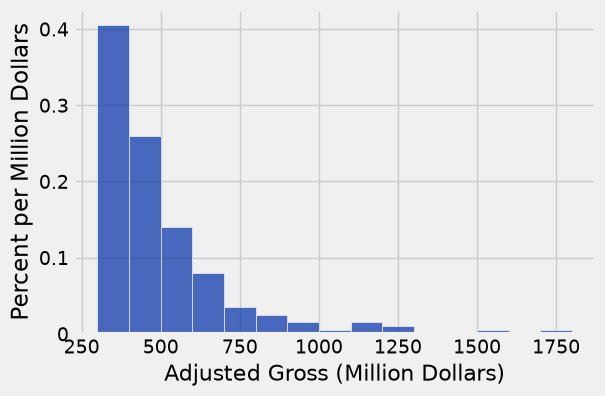

In [72]:
millions.hist('Adjusted Gross', bins=np.arange(300, 1801, 100), unit='Million Dollars')

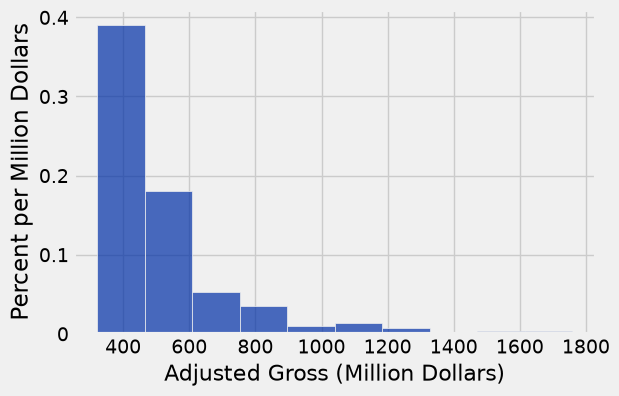

In [73]:
millions.hist('Adjusted Gross', unit='Million Dollars') # by default it makes the same 10 bins

---